# Exploratory Data Analysis

The goal is to understand customer demographics and purchasing behaviour before segmentation.

We start by importing the required libraries and loading the pre-processed customer features dataset.


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

feature_data = pd.read_csv('../data/processed/customer_features.csv')


## 1. Univariate Analysis

We explore the distribution of key numerical features individually to understand their spread and shape.

### 1.1 Age Distribution

The histogram below shows the distribution of customer ages across the dataset. The KDE curve helps visualise the overall density shape.

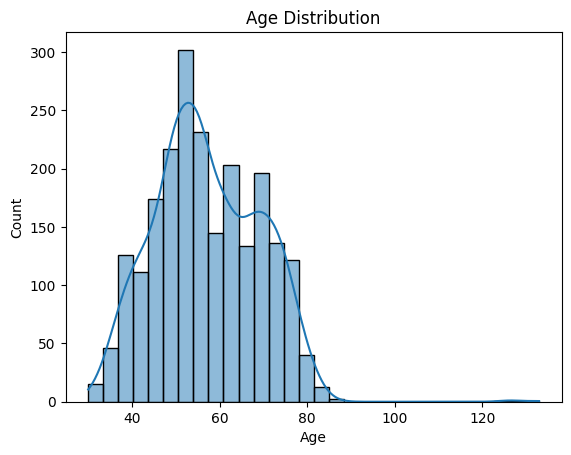

In [7]:
# Age Distribution
sns.histplot(feature_data["Age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

The histogram reveals a **right-skewed distribution** of customer ages:
 
- The majority of customers fall between **30 and 75 years old**, with a sharp peak around **50–55 years**.
- A secondary, smaller bump appears around **65–70**, suggesting a mild bimodal pattern.
- A handful of customers appear above **100 years old** (up to ~130), almost certainly **data quality issues** rather than real ages.
> **Implication for segmentation:** Age groups should cover the dominant 30–75 range, and records above ~100 should be treated as outliers/errors.

### 1.2 Income Distribution

We examine the distribution of annual income. Right-skewed distributions can indicate the presence of high-income outliers.

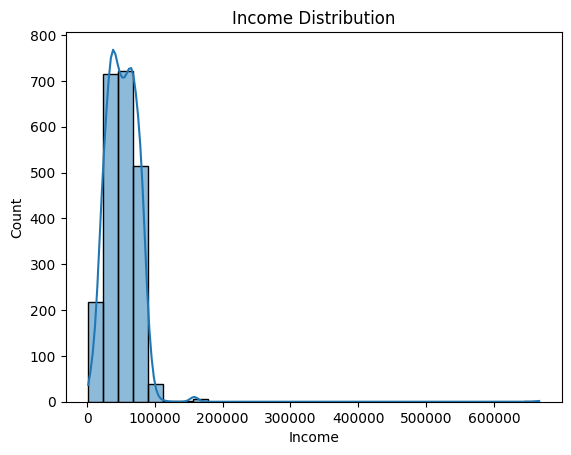

In [8]:
#Income Distribution
sns.histplot(feature_data["Income"],bins=30,kde=True)
plt.title("Income Distribution")
plt.show()

The histogram reveals a **heavily right-skewed distribution** of customer income:

- The vast majority of customers earn between **$0 and $100,000**, with a sharp peak around **$50,000–$75,000**.
- The distribution drops off steeply after **$100,000**, with very few customers beyond that threshold.
- The **long right tail** extends all the way to ~$666,000, indicating the presence of **extreme high-income outliers** that are likely to distort mean-based statistics.
- The KDE curve confirms the sharp, narrow peak and the heavy skew toward the right.

> **Implication for segmentation:** It is advisable to **cap or log-transform** the income feature before clustering to prevent outliers from disproportionately influencing distance-based algorithms such as K-Means.

### 1.3 Total Spending Distribution

Total spending captures the sum of all purchases made by each customer. This metric will be a key variable in the segmentation phase.

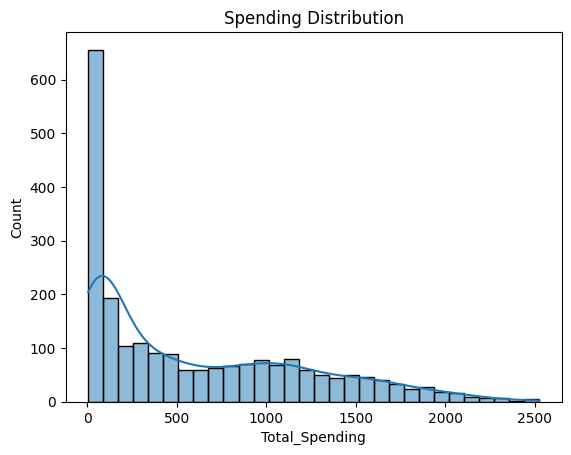

In [9]:
#Spending Distribution
sns.histplot(feature_data["Total_Spending"],bins=30,kde=True)
plt.title("Spending Distribution")
plt.show()

The histogram reveals a **strongly right-skewed distribution** of customer total spending:
 
- A **large spike near $0–$100** dominates, indicating a significant share of low spenders or near-inactive customers.
- Beyond that spike, the count **decreases gradually and continuously** up to ~$2,500 — there is no sharp drop at $500, just a long, slow decay.
- A subtle, slightly elevated plateau is visible around **$900–$1,200**, hinting at a possible subgroup of moderate spenders, though it is not very pronounced.
> **Implication for segmentation:** The strong concentration near zero suggests at least two groups (low spenders vs. the rest). A log-transformation may help reduce the dominance of the zero-spike.
 

## 2. Bivariate Analysis

Here we explore relationships between pairs of features using box plots to highlight differences across categorical groups.

### 2.1 Income by Education Level

This box plot compares income distributions across different education levels. We can identify whether higher education correlates with higher income.

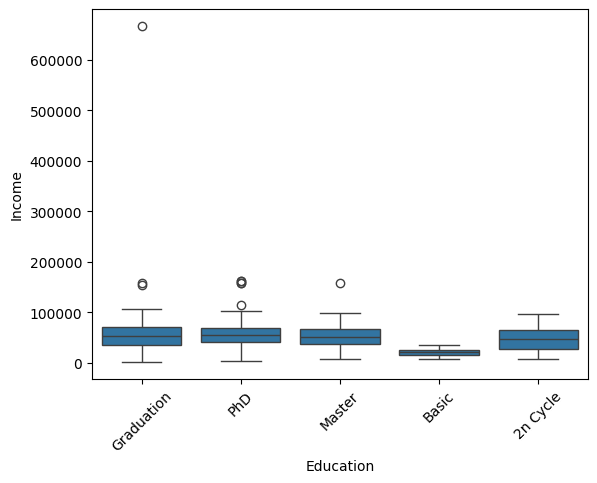

In [11]:
sns.boxplot(x='Education', y='Income', data=feature_data)
plt.xticks(rotation=45)
plt.show()

The boxplot does **not** show a steady, linear increase in income with education:
 
- **Basic** is clearly the lowest-income group (median ~$20k), well below all other levels.
- **Graduation, 2nd Cycle, Master, and PhD** all have **very similar median incomes** (~$50k–$55k) — there is no clean progression among them.
- Several **outliers are clearly visible**, including one extreme value near $666k (Graduation) and multiple values around $150k–$160k (Graduation, PhD, Master) — these are *not* outlier-free distributions.
> **Implication for segmentation:** Education mainly separates "Basic" from everyone else; it does not finely discriminate among the other four levels. Outliers should be handled (capping/log-transform) before using Income in clustering.

### 2.2 Total Spending by Marital Status

This box plot shows how total spending varies by marital status. Some groups may have notably different spending behaviours.

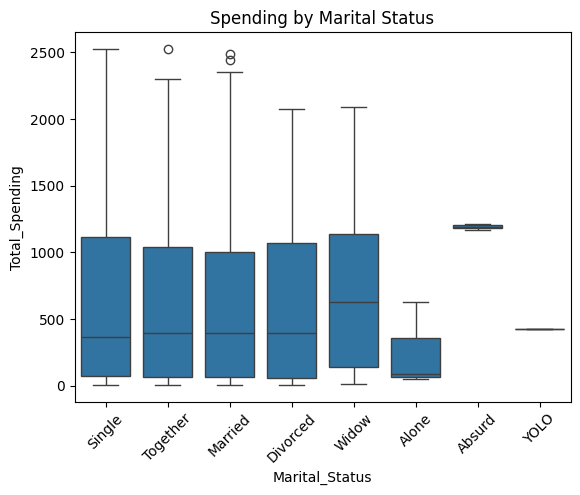

In [12]:
sns.boxplot(x="Marital_Status",y="Total_Spending", data=feature_data)
plt.xticks(rotation=45)
plt.title("Spending by Marital Status")
plt.show()

 
- **Single, Together, Married, and Divorced** show **very similar median spending** (~$350–$400) — none of them stands out as clearly higher than the others.
- **Widow** actually has the **highest median spending** (~$625) among the standard categories, contrary to what might be expected.
- **Alone** has the **lowest spending**, with a narrow, low range (median ~$75–$100).
- **Absurd** is not erratic or low — it forms a **tight, high cluster** around $1,150–$1,200. **YOLO** is a single data point (~$425), too sparse to draw conclusions from.
> **Implication for segmentation:** Marital status differentiates mainly "Alone" (low) and "Widow" (high) from the rest; "Absurd" and "YOLO" are likely data-entry artifacts and should be cleaned or excluded rather than treated as real categories.
 

## 3. Multivariate Analysis

We now look at interactions between multiple variables simultaneously using correlation matrices and pivot heatmaps.

### 3.1 Correlation Matrix

The heatmap below displays pairwise Pearson correlations between key numerical features. Strong positive or negative correlations may reveal redundant or complementary features for segmentation.

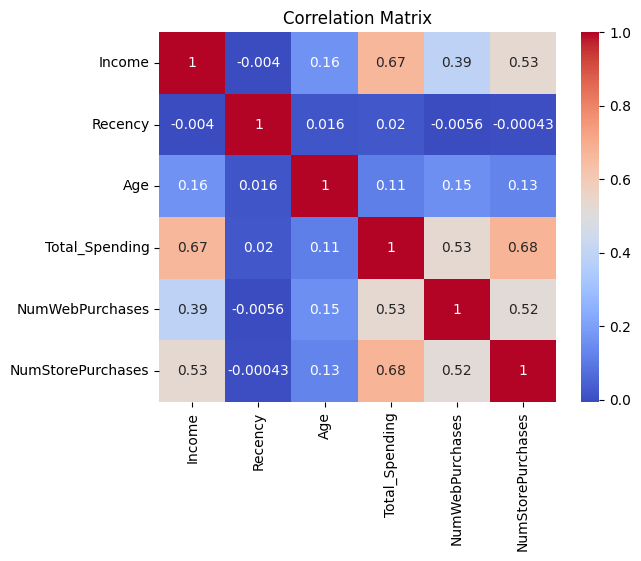

In [13]:
correlation = feature_data[["Income","Recency","Age","Total_Spending","NumWebPurchases","NumStorePurchases"]].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

- **Total_Spending** is strongly positively correlated with **Income** (0.67), **NumWebPurchases** (0.53), and **NumStorePurchases** (0.68). This suggests that higher spenders tend to have higher income and make more purchases across both channels.

- **Income** is moderately correlated with **NumWebPurchases** (0.39) and **NumStorePurchases** (0.53), indicating that wealthier customers tend to buy more, especially in-store.

- **Age** and **Recency** show very weak correlations with most variables (near 0), meaning they capture relatively independent information.

- **NumWebPurchases** and **NumStorePurchases** are moderately correlated (0.52), suggesting some overlap but not full redundancy.

Overall, **Total_Spending**, **Income**, and purchase-related features are closely linked, while **Age** and **Recency** bring distinct dimensions to the dataset.

### 3.2 Average Income by Education and Marital Status

This pivot table heatmap reveals how average income varies across the intersection of education level and marital status, exposing potential interaction effects.

C:\Users\Cyrille PIO\AppData\Local\Temp\ipykernel_2308\3259427360.py:1: FutureWarning: The provided callable <function mean at 0x00000223B843E0C0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_income = feature_data.pivot_table(index="Education", values="Income", columns="Marital_Status", aggfunc=np.mean)


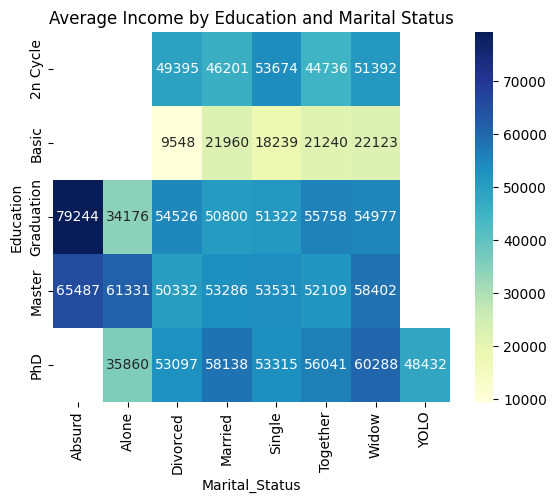

In [15]:
pivot_income = feature_data.pivot_table(index="Education", values="Income", columns="Marital_Status", aggfunc=np.mean)

sns.heatmap(pivot_income, annot=True, cmap="YlGnBu", fmt=".0f")
plt.title("Average Income by Education and Marital Status")
plt.show()

- **Basic** is consistently the lowest-income group across all marital statuses (~$9k–$22k).
- Among the other education levels, the picture is **mixed rather than systematic**: PhD/Master are highest for some marital statuses (e.g., Married, Widow, Together), but for **Divorced** and **Single**, Graduation or 2nd Cycle is comparable to or even higher than PhD/Master.
- **Absurd** and **YOLO** are **not** low or erratic: Absurd/Graduation shows **$79,244**, the single highest value in the entire table. These categories likely reflect small sample sizes rather than genuinely low income.
> **Implication for segmentation:** Education level (specifically Basic vs. the rest) is the dominant driver of income; the interaction with marital status is inconsistent and should not be over-interpreted given the small group sizes for non-standard categories.

## 4. Group-Level Analysis

We aggregate spending and behavioural metrics by demographic groups to surface high-level patterns.

### 4.1 Average Spending by Education Level

This bar chart ranks education levels by their mean total spending. It helps identify which customer segments tend to be the highest spenders.

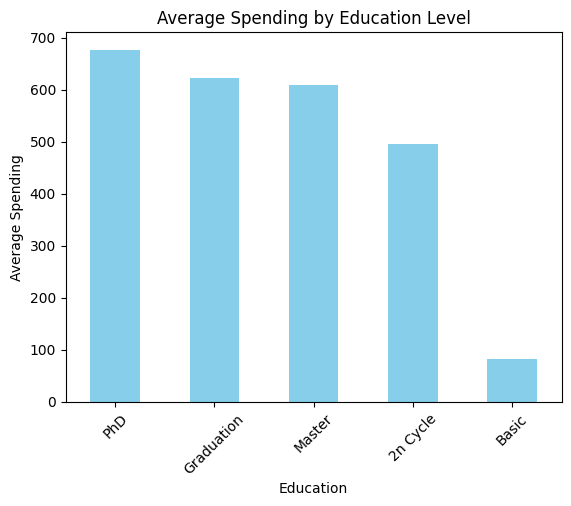

In [16]:
#Average Spending by Education
average_spending_by_education = feature_data.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

average_spending_by_education.plot(kind="bar", color="skyblue")
plt.title("Average Spending by Education Level")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.show()

- **PhD** holders show the highest average spending, around **675 units**.
- **Graduation** and **Master** follow closely, around **600–625 units**.
- **2nd Cycle** drops to about **495 units**.
- **Basic** collapses to roughly **80 units** — far below "400", a much steeper drop than the other levels suggest.
The relationship is not a smooth, even decline: there is a relatively gentle slope from PhD down to 2nd Cycle, followed by a **sharp cliff** at Basic.
 
> **Implication for segmentation:** Basic-education customers form a clearly separate, very-low-spending group, while the other four levels differentiate much less from each other.

### 4.2 Campaign Acceptance Rate by Marital Status

This chart shows the average campaign acceptance rate per marital status group. Groups with higher acceptance rates are promising targets for future marketing campaigns.

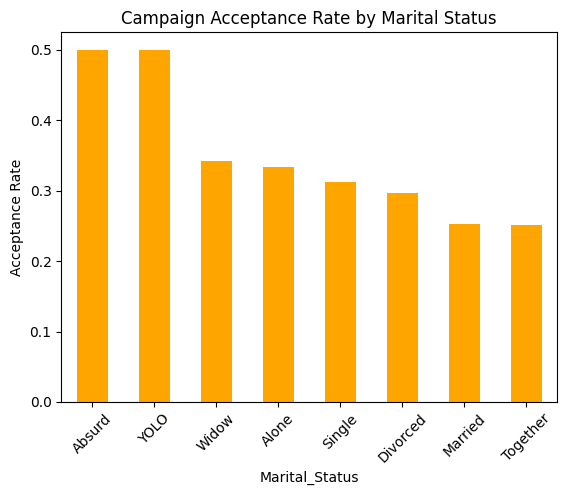

In [17]:
campaign_acceptance_by_marital_status = feature_data.groupby("Marital_Status")["accepted_campaigns"].mean().sort_values(ascending=False)

campaign_acceptance_by_marital_status.plot(kind="bar",color="Orange")

plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=45)
plt.show()

- **Absurd** and **YOLO** show the **highest** acceptance rates (~0.50), though these groups are very small and likely unreliable.
- **Widow, Alone, Single, and Divorced** fall in a **middle range** (~0.30–0.34).
- **Married and Together** show the **lowest** acceptance rates (~0.25).
> **Implication for segmentation:** Among the standard categories, single/divorced/widowed/alone customers respond somewhat better to campaigns than married or partnered customers — the opposite of what couples-focused targeting would assume. The Absurd/YOLO results should be treated cautiously given likely tiny sample sizes.

### 4.3 Average Income by Age Group

This horizontal bar chart displays average income by age group. Understanding income brackets across age ranges will inform customer segmentation strategies.

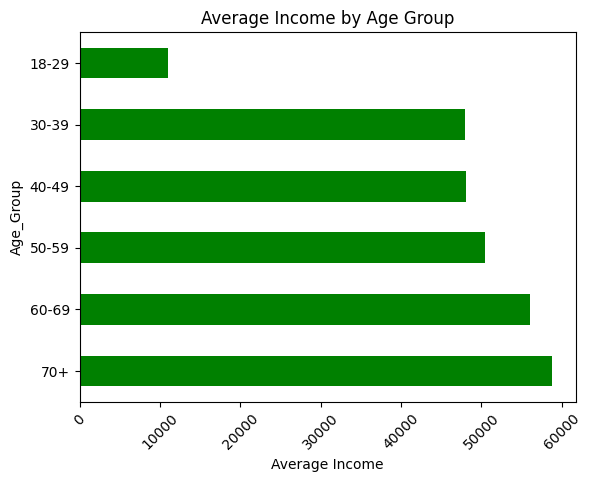

In [18]:
Income_by_Age_Group = feature_data.groupby("Age_Group")["Income"].mean().sort_values(ascending=False)

Income_by_Age_Group.plot(kind="barh", color="Green")
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.xticks(rotation=45)
plt.show()

The horizontal bar chart shows a **clear, monotonic increase** in average income with age:
 
- The **18–29** group has the lowest average income (~$11k).
- Income rises steadily through **30–39, 40–49, 50–59**, reaching roughly **$48k–$51k**.
- **60–69** and **70+** show the highest average incomes, around **$56k** and **$59k** respectively.
> **Implication for segmentation:** Age group is a useful, consistent proxy for income level and could complement Income as a segmentation feature, particularly for distinguishing younger, lower-income customers from older, higher-income ones